# Airbnb Metrics Exploration

This notebook explores the derived metrics produced by the EMR PySpark job. It assumes you have already downloaded the Parquet outputs from S3 into a local `${workspaceRoot}/results/` directory (for example via `aws s3 sync s3://data228-emr-data-bucket/airbnb/metrics/santa_clara_county/<date>/ ${workspaceRoot}/results/`).

## 1. Configuration

Update the paths or snapshot date below if your local directory layout differs.

In [13]:
from pathlib import Path
import os

# Root directory where metric subfolders live (each subfolder contains Parquet parts)
METRICS_ROOT = Path('../results')

# Allow override via environment variable, e.g. export AIRBNB_METRICS_ROOT=/path/to/metrics
env_override = os.getenv('A IRBNB_METRICS_ROOT')
if env_override:
    METRICS_ROOT = Path(env_override)

if not METRICS_ROOT.exists():
    raise FileNotFoundError(
        f"Metrics root directory not found: {METRICS_ROOT.resolve()} "
        "Run `aws s3 sync` first or adjust METRICS_ROOT above."
    )

print(f"Using metrics root: {METRICS_ROOT.resolve()}")


Using metrics root: /Users/hiruzen/Programming/Projects/DATA-228-Projects/hw1/EMR/results


## 2. Helper Functions

We will load each metric into a pandas DataFrame for analysis.

In [6]:
import pandas as pd
from typing import Dict

METRIC_FOLDERS: Dict[str, str] = {
    'neighbourhood_investment': 'Neighbourhood-level revenue and demand trends',
    'dynamic_pricing': 'Pricing distributions and booking response',
    'minimum_stay': 'Minimum-night policy performance',
    'amenity_roi': 'Amenity occupancy/revenue lift',
    'seasonality': 'Seasonality indices by scope',
    'host_performance': 'Host-level quality and demand indicators',
    'portfolio_mix': 'Property + room type benchmarks',
    'supply_saturation': 'Supply vs demand change',
    'compliance_exposure': 'Regulatory risk flags',
    'fee_optimization': 'Fee contribution to realized revenue'
}

def available_metrics(root: Path) -> Dict[str, Path]:
    "Return metric directories that exist under the root."
    return {name: root / name for name in METRIC_FOLDERS if (root / name).exists()}

def load_metric(name: str) -> pd.DataFrame:
    "Load a metric DataFrame from the local Parquet directory."
    path = METRICS_ROOT / name
    if not path.exists():
        raise FileNotFoundError(f"Metric directory not found: {path}")
    return pd.read_parquet(path)

metrics_present = available_metrics(METRICS_ROOT)
if not metrics_present:
    raise RuntimeError(f"No known metric folders located under {METRICS_ROOT}")

print(f"Loaded metadata for {len(metrics_present)} metrics:")
for metric_name, description in METRIC_FOLDERS.items():
    print(f"{metric_name:24s} - {description}")


Loaded metadata for 10 metrics:
neighbourhood_investment - Neighbourhood-level revenue and demand trends
dynamic_pricing          - Pricing distributions and booking response
minimum_stay             - Minimum-night policy performance
amenity_roi              - Amenity occupancy/revenue lift
seasonality              - Seasonality indices by scope
host_performance         - Host-level quality and demand indicators
portfolio_mix            - Property + room type benchmarks
supply_saturation        - Supply vs demand change
compliance_exposure      - Regulatory risk flags
fee_optimization         - Fee contribution to realized revenue


## 3. Neighbourhood Investment Opportunities

Identify neighbourhoods delivering the strongest revenue per available room (RevPAR) and improving demand.

In [14]:
import numpy as np

neighbourhood_df = load_metric('neighbourhood_investment')
print(f"Rows: {len(neighbourhood_df):,}; Columns: {list(neighbourhood_df.columns)}")

latest_month = neighbourhood_df['month_start'].max()
latest_snapshot = neighbourhood_df[neighbourhood_df['month_start'] == latest_month]

summary = (
    latest_snapshot
    .dropna(subset=['revpar', 'booking_rate'])
    .sort_values(['revpar', 'booking_rate'], ascending=False)
    .head(15)
    [['neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'revpar', 'booking_rate', 'fee_share']]
)
summary.style.background_gradient(subset=['revpar'], cmap='Greens')


Rows: 208; Columns: ['neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'month_start', 'active_listings', 'booked_nights', 'available_nights', 'booked_revenue', 'total_revenue', 'fee_revenue', 'avg_listed_price', 'avg_accommodates', 'total_nights', 'revpar', 'booking_rate', 'supply_per_listing', 'fee_share', 'revpar_change_pct', 'booking_rate_change_pct', 'rolling_booking_rate', 'long_term_booking_rate', 'demand_index']


,neighbourhood_cleansed,neighbourhood_group_cleansed,revpar,booking_rate,fee_share
77,Los Gatos,West Valley,3410.696483,0.686544,0.120000
12,Campbell,West Valley,726.913899,0.599795,0.120000
168,Santa Clara,Silicon Valley Core,472.001066,0.507685,0.120000
64,Los Altos Hills,Peninsula,428.811392,0.683544,0.120000
142,Palo Alto,Peninsula,182.693431,0.604612,0.120000
103,Monte Sereno,West Valley,136.222345,0.601770,0.120000
181,Saratoga,West Valley,130.361722,0.561050,0.120000
51,Los Altos,Peninsula,122.384336,0.694646,0.120000
207,Unincorporated Areas,South County,105.734078,0.542737,0.120000
116,Morgan Hill,South County,104.317623,0.459016,0.120000


### Trend Visualisation

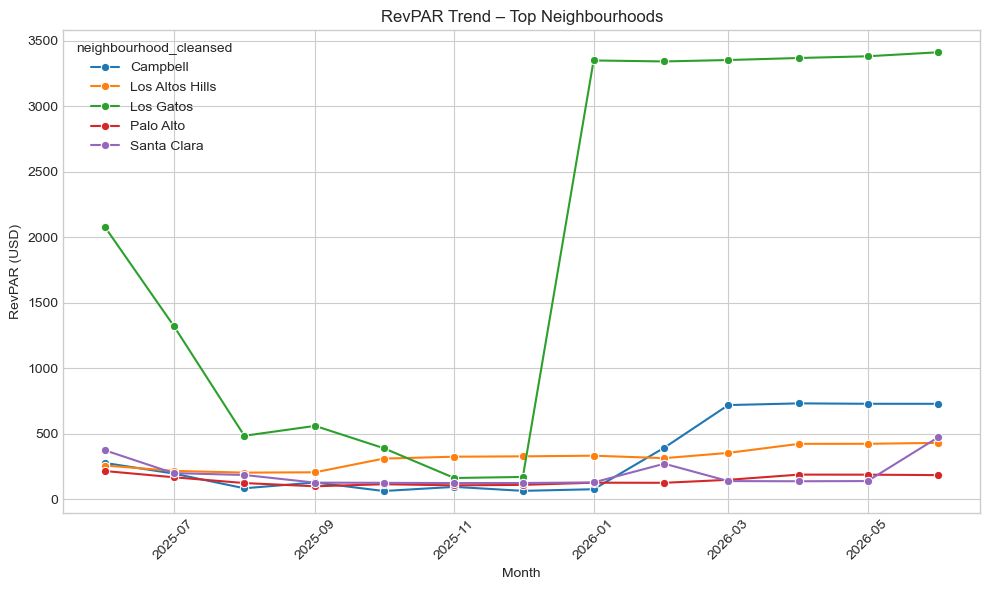

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

target_neighbourhoods = summary['neighbourhood_cleansed'].head(5).tolist()
trend_df = neighbourhood_df[neighbourhood_df['neighbourhood_cleansed'].isin(target_neighbourhoods)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=trend_df,
    x='month_start',
    y='revpar',
    hue='neighbourhood_cleansed',
    marker='o',
    ax=ax
)
ax.set_title('RevPAR Trend – Top Neighbourhoods')
ax.set_xlabel('Month')
ax.set_ylabel('RevPAR (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Minimum-Stay Policy Insights

Assess how minimum-night requirements correlate with occupancy and revenue.

In [16]:
min_stay_df = load_metric('minimum_stay')
print(min_stay_df.head())

policy_summary = (
    min_stay_df
    .sort_values(['room_type', 'minimum_stay_bucket'])
    [['minimum_stay_bucket', 'room_type', 'listing_count', 'median_occupancy', 'avg_booked_revenue']]
)
policy_summary.head(10)


  minimum_stay_bucket        room_type  listing_count  median_occupancy  \
0        01_one-night  Entire home/apt            823          0.410959   
1        01_one-night       Hotel room            141          0.139726   
2        01_one-night     Private room           1026          0.282192   
3        01_one-night      Shared room             26          0.126027   
4     02_two-to-three  Entire home/apt           1423          0.490411   

   avg_occupancy  avg_booked_revenue     avg_price  
0       0.470414        42581.557716    338.892598  
1       0.290858       506374.421986  11314.513514  
2       0.432303        40737.633528    561.766234  
3       0.136143         2178.461538     43.269231  
4       0.513590        41222.456430    280.875105  


,minimum_stay_bucket,room_type,listing_count,median_occupancy,avg_booked_revenue
0,01_one-night,Entire home/apt,823,0.410959,42581.557716
4,02_two-to-three,Entire home/apt,1423,0.490411,41222.456430
8,03_four-to-six,Entire home/apt,300,0.635616,41052.020000
11,04_one-to-two-weeks,Entire home/apt,136,0.608219,58460.606618
14,05_two-to-four-weeks,Entire home/apt,264,0.394521,31684.526515
17,06_thirty-plus,Entire home/apt,866,0.208219,37239.896651
1,01_one-night,Hotel room,141,0.139726,506374.421986
5,02_two-to-three,Hotel room,2,0.328767,21600.000000
2,01_one-night,Private room,1026,0.282192,40737.633528
6,02_two-to-three,Private room,612,0.635616,21388.098039


## 5. Amenity ROI

Compare occupancy and revenue lift for high-impact amenities.

In [17]:
amenity_df = load_metric('amenity_roi')
amenity_df.sort_values('occupancy_lift', ascending=False)


,amenity,listings_with,listings_without,occupancy_with,occupancy_without,occupancy_lift,revenue_with,revenue_without,revenue_lift
7,Washer,3543,3380,0.485854,0.457348,0.028505,34494.477300,58003.769280,-23509.291980
4,Free parking on premises,4582,2341,0.480406,0.455564,0.024842,38941.266753,59565.406480,-20624.139727
1,Wifi,6326,597,0.473011,0.461230,0.011781,46765.317478,36959.360759,9805.956718
0,Air conditioning,3817,3106,0.456306,0.491591,-0.035285,56653.071569,32521.884050,24131.187518
3,Self check-in,4756,2167,0.458522,0.502234,-0.043712,52216.120306,31799.417255,20416.703051
2,Dedicated workspace,4684,2239,0.457725,0.501545,-0.043820,51046.446713,35312.887058,15733.559655
6,Hot tub,438,6485,0.423490,0.475449,-0.051959,31110.928571,46975.535738,-15864.607167
5,Pool,955,5968,0.357698,0.491304,-0.133606,33772.889666,47973.912273,-14201.022606


## 6. Pricing Elasticity Snapshot

Evaluate how median pricing compares to the neighbourhood average and how it affects booking rate.

In [18]:
dynamic_df = load_metric('dynamic_pricing')
latest_month = dynamic_df['month_start'].max()
latest_dynamic = dynamic_df[dynamic_df['month_start'] == latest_month]

pricing_view = (
    latest_dynamic
    .assign(
        price_delta=lambda df: df['median_price'] - df['median_price_region'],
        booking_vs_median=lambda df: df['booking_rate'] - df['booking_rate'].median()
    )
    [['neighbourhood_cleansed', 'room_type', 'median_price', 'median_price_region', 'price_delta', 'booking_rate', 'booking_vs_median']]
    .sort_values('price_delta', ascending=False)
)
pricing_view.head(10)


,neighbourhood_cleansed,room_type,median_price,median_price_region,price_delta,booking_rate,booking_vs_median
259,Monte Sereno,Private room,67.0,61.461538,5.538462,0.252747,-0.318361
324,Mountain View,Shared room,55.0,50.384615,4.615385,0.000000,-0.571109
129,Los Altos,Private room,130.0,127.230769,2.769231,0.718069,0.146960
415,San Jose,Private room,89.0,88.076923,0.923077,0.540109,-0.031000
467,Santa Clara,Private room,87.0,86.076923,0.923077,0.524880,-0.046229
38,Campbell,Private room,128.0,127.538462,0.461538,0.571109,0.000000
579,Unincorporated Areas,Private room,72.0,71.923077,0.076923,0.621863,0.050754
510,Sunnyvale,Entire home/apt,180.0,180.000000,0.000000,0.398695,-0.172414
506,Saratoga,Private room,114.0,114.000000,0.000000,0.519886,-0.051222
526,Sunnyvale,Hotel room,132.5,132.500000,0.000000,0.759197,0.188089


## 7. Supply Saturation Check

Flag neighbourhoods where supply growth coincides with falling occupancy.

In [19]:
supply_df = load_metric('supply_saturation')
latest_period = supply_df['month_start'].max()
latest_supply = supply_df[supply_df['month_start'] == latest_period]

risk_table = (
    latest_supply
    .assign(risk_flag=lambda df: (df['growth_flag'].fillna(False)) & (df['risk_score'] > 0))
    .sort_values('risk_score', ascending=False)
    [['neighbourhood_cleansed', 'active_listings', 'active_listing_growth', 'occupancy_trend', 'revenue_trend', 'risk_score', 'risk_flag']]
)
risk_table.head(10)


/var/folders/f_/lrnlktqj03s07c5mg2wkxk840000gn/T/ipykernel_79828/2962274139.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(risk_flag=lambda df: (df['growth_flag'].fillna(False)) & (df['risk_score'] > 0))


,neighbourhood_cleansed,active_listings,active_listing_growth,occupancy_trend,revenue_trend,risk_score,risk_flag
2948,Santa Clara,207,189.0,-0.162934,-13486.950855,13487.113790,True
1325,Monte Sereno,4,3.0,-0.252747,-718.192308,718.445055,True
878,Los Altos Hills,3,1.0,-0.594203,469.702415,470.296618,True
2115,Palo Alto,4,3.0,-0.505495,-316.296703,316.802198,True
1446,Morgan Hill,4,3.0,-0.760417,-227.255208,228.015625,True
3884,Unincorporated Areas,19,17.0,-0.527523,-193.631881,194.159404,True
1455,Morgan Hill,9,4.0,-0.049140,-190.689685,190.738825,True
1686,Mountain View,36,23.0,-0.528870,-133.918458,134.447328,True
876,Los Altos Hills,7,6.0,-0.136646,-126.540373,126.677019,True
3153,Saratoga,21,12.0,-0.034161,123.227752,123.261913,True
